
# 📊 Análisis de Ventas (Proyecto Portfolio)

## 🎯 Objetivo
Analizar el comportamiento de ventas para identificar:
- Productos más rentables
- Estacionalidad
- Oportunidades de negocio

## 🛠️ Tecnologías
- Python
- Pandas
- Seaborn
- Matplotlib


In [3]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:

df = pd.read_csv("sales_data_sample.csv", encoding="latin1")

df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], errors='coerce')
df['SALES'] = pd.to_numeric(df['SALES'], errors='coerce')

df = df.dropna()

df['MONTH'] = df['ORDERDATE'].dt.month
df['YEAR'] = df['ORDERDATE'].dt.year

df.head()


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,MONTH,YEAR
10,10223,37,100.00,1,3965.66,2004-02-20,Shipped,1,2,2004,...,Melbourne,Victoria,3004,Australia,APAC,Ferguson,Peter,Medium,2,2004
21,10361,20,72.55,13,1451.00,2004-12-17,Shipped,4,12,2004,...,Chatswood,NSW,2067,Australia,APAC,Huxley,Adrian,Small,12,2004
40,10270,21,100.00,9,4905.39,2004-07-19,Shipped,3,7,2004,...,Chatswood,NSW,2067,Australia,APAC,Huxley,Adrian,Medium,7,2004
47,10347,30,100.00,1,3944.70,2004-11-29,Shipped,4,11,2004,...,Melbourne,Victoria,3004,Australia,APAC,Ferguson,Peter,Medium,11,2004
51,10391,24,100.00,4,2416.56,2005-03-09,Shipped,1,3,2005,...,North Sydney,NSW,2060,Australia,APAC,O'Hara,Anna,Small,3,2005


In [5]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,MSRP,MONTH,YEAR
count,147.000000,147.000000,147.000000,147.000000,147.000000,147,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000
mean,10268.204082,33.986395,84.138639,6.673469,3446.003537,2004-05-30 10:46:31.836734720,2.673469,6.986395,2003.863946,100.632653,6.986395,2003.863946
min,10120.000000,15.000000,26.880000,1.000000,652.350000,2003-04-29 00:00:00,1.000000,1.000000,2003.000000,33.000000,1.000000,2003.000000
25%,10148.000000,26.000000,66.390000,3.000000,2249.005000,2003-09-11 00:00:00,2.000000,4.000000,2003.000000,70.000000,4.000000,2003.000000
50%,10270.000000,33.000000,98.050000,6.000000,3160.740000,2004-07-19 00:00:00,3.000000,7.000000,2004.000000,99.000000,7.000000,2004.000000
75%,10361.000000,41.000000,100.000000,10.000000,4410.060000,2004-12-17 00:00:00,4.000000,11.000000,2004.000000,121.000000,11.000000,2004.000000
max,10420.000000,66.000000,100.000000,15.000000,9774.030000,2005-05-29 00:00:00,4.000000,12.000000,2005.000000,214.000000,12.000000,2005.000000
std,106.742036,9.740458,19.897255,3.830596,1717.988835,NaN,1.171367,3.734303,0.746127,40.046562,3.734303,0.746127


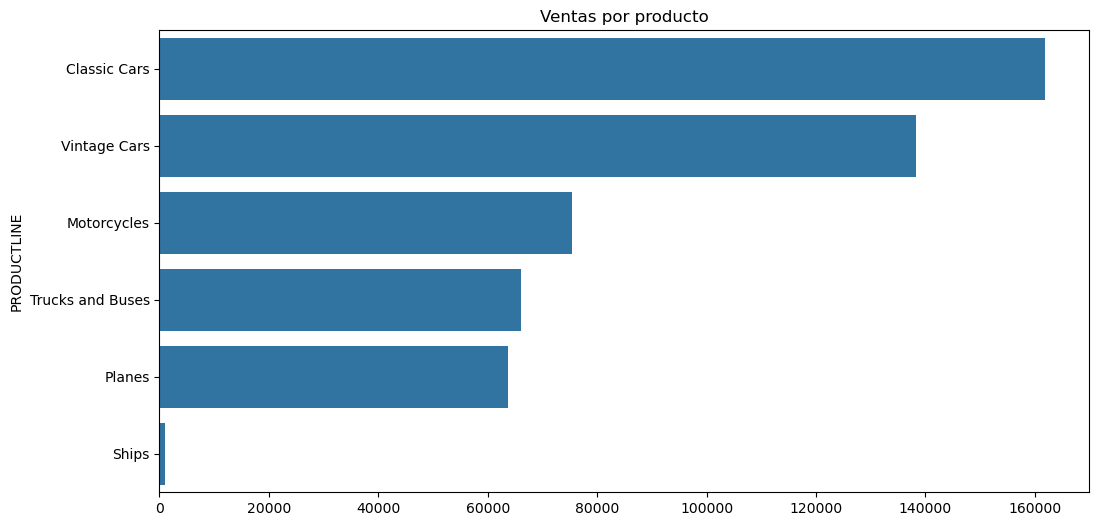

PRODUCTLINE
Classic Cars        161870.46
Vintage Cars        138332.98
Motorcycles          75476.67
Trucks and Buses     66020.96
Planes               63772.09
Ships                 1089.36
Name: SALES, dtype: float64

In [6]:

ventas_producto = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=ventas_producto.values, y=ventas_producto.index)
plt.title("Ventas por producto")
plt.show()

ventas_producto


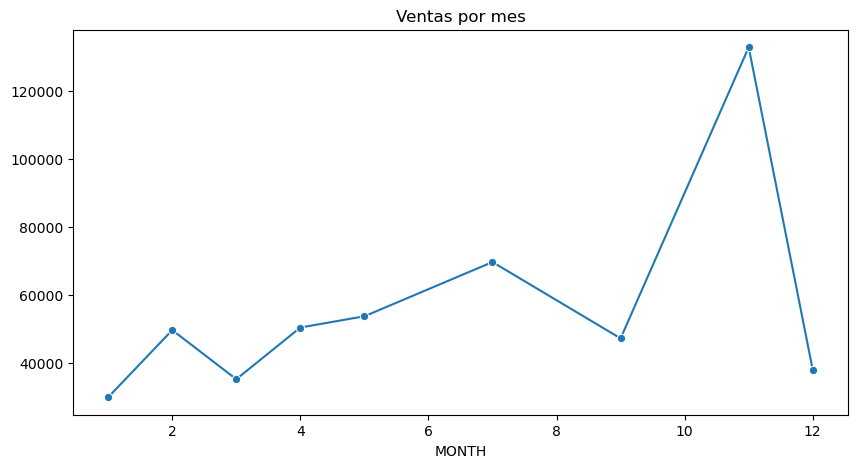

In [7]:

ventas_mes = df.groupby('MONTH')['SALES'].sum()

plt.figure(figsize=(10,5))
sns.lineplot(x=ventas_mes.index, y=ventas_mes.values, marker="o")
plt.title("Ventas por mes")
plt.show()


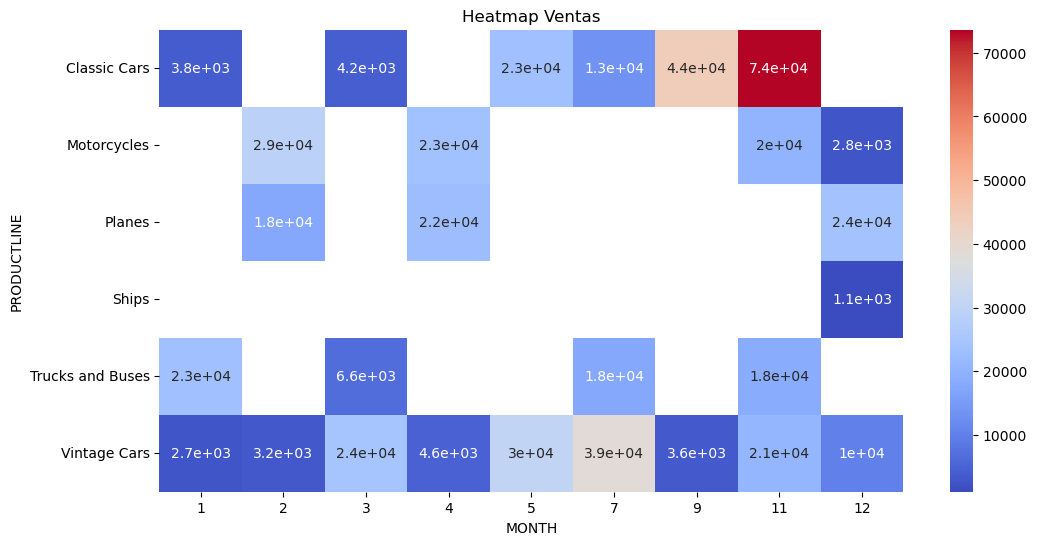

In [8]:

pivot = df.pivot_table(
    values='SALES',
    index='PRODUCTLINE',
    columns='MONTH',
    aggfunc='sum'
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="coolwarm", annot=True)
plt.title("Heatmap Ventas")
plt.show()


In [10]:

top_clientes = df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False).head(10)
top_clientes


CUSTOMERNAME
Australian Collectors, Co.    200995.41
Anna's Decorations, Ltd       153996.13
Souveniers And Things Co.     151570.98
Name: SALES, dtype: float64


## 📌 Conclusiones

- Classic Cars lidera ventas
- Existe estacionalidad clara
- Pocos clientes concentran ingresos

## 🚀 Recomendaciones
- Focalizar productos top
- Aprovechar meses pico
- Fidelizar clientes clave
